# 412024030 - Davidson Rafael Krisman Nugroho - Computer Vision

# Praktikum 03 — Dasar Deep Learning untuk CV
### Perceptron, Multi-Layer Perceptron, Backpropagation, Fungsi Loss & Optimasi

Selamat datang di Sesi 3! Kalian baru saja mendapat materi teori dari Bu Endah tentang:
perceptron, fungsi aktivasi, fungsi loss, *chain rule* pada backpropagation, dan
algoritma optimasi (SGD, Adam, AdamW). Notebook ini adalah tempat kalian **membuktikan
sendiri** bahwa matematika yang baru dijelaskan itu benar-benar bekerja — dengan tangan
kalian sendiri, lalu dengan PyTorch, lalu di dataset citra sungguhan.

**Struktur (± 50 menit):**
| Bagian | Tugas | Alokasi |
|---|---|---|
| A | Neuron & Backprop Manual (NumPy murni, dataset XOR) | 15 menit |
| B | Dari NumPy ke `nn.Module` (verifikasi identik) | 15 menit |
| C | Training Loop Nyata di FashionMNIST | 20 menit |
| Bonus | Perbandingan Optimizer & LR Scheduler | jika waktu tersisa |

**Cara pakai:** setiap sel bertanda `# TODO` wajib diisi. Setelah mengisi satu blok TODO,
jalankan **Sel Pemeriksa** di bawahnya — jika ada `assert` yang gagal, itu artinya
implementasimu belum benar. Kalau stuck lebih dari beberapa menit, buka blok
**💡 Kode Penyelamat** yang disediakan (collapsible, jangan diintip duluan!).

## 0️⃣ Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)
print("Torch:", torch.__version__, "| CUDA tersedia:", torch.cuda.is_available())

Torch: 2.11.0+cpu | CUDA tersedia: False


---
## Bagian A — Neuron & Backprop Manual (Tugas 1)

Kita mulai dari masalah klasik yang **tidak bisa** diselesaikan satu perceptron saja:
**XOR**. Empat titik di 2D, dua kelas, tapi tidak ada satu garis lurus pun yang bisa
memisahkannya — inilah alasan matematis kenapa kita butuh *hidden layer* (ingat: tanpa
fungsi aktivasi non-linear, tumpukan banyak layer linear tetap cuma jadi satu fungsi
linear — persis yang dijelaskan Bu Endah di Sesi 1).

### Data: dataset XOR (non-linearly separable)

Dataset XOR: (240, 2) (240, 1) | proporsi kelas 1: 0.5


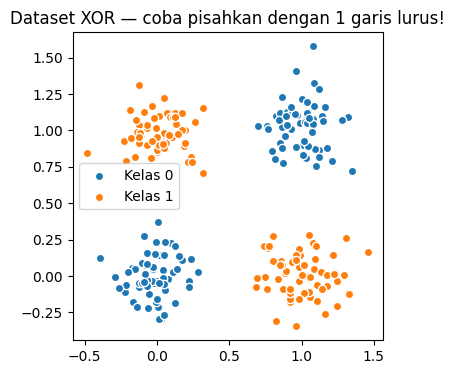

In [2]:
def make_xor(n_per_cluster=60, noise=0.15, seed=42):
    '''4 klaster di sekitar (0,0),(1,1),(0,1),(1,0). Label XOR: (0,0)&(1,1) -> kelas 0, sisanya -> kelas 1.'''
    rng = np.random.RandomState(seed)
    centers = np.array([[0, 0], [1, 1], [0, 1], [1, 0]])
    labels = np.array([0, 0, 1, 1])
    X, y = [], []
    for c, lab in zip(centers, labels):
        pts = c + rng.randn(n_per_cluster, 2) * noise
        X.append(pts); y.append(np.full(n_per_cluster, lab))
    X = np.vstack(X).astype(np.float64)
    y = np.concatenate(y).astype(np.float64).reshape(-1, 1)
    perm = rng.permutation(len(X))
    return X[perm], y[perm]

X, y = make_xor()
print("Dataset XOR:", X.shape, y.shape, "| proporsi kelas 1:", y.mean())

plt.figure(figsize=(4, 4))
plt.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], label="Kelas 0", edgecolors="white")
plt.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], label="Kelas 1", edgecolors="white")
plt.legend(); plt.title("Dataset XOR — coba pisahkan dengan 1 garis lurus!")
plt.show()

### TODO 1 — Forward Pass Manual

Arsitektur: `Linear(2->8) -> ReLU -> Linear(8->1) -> Sigmoid`.

Ingat notasi dari slide teori: $z = Wx + b$ (transformasi afin), lalu $a = \sigma(z)$
(aktivasi). Isi 4 baris yang masih `None` di bawah.

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def init_params(in_dim=2, hid_dim=8, out_dim=1, seed=0):
    rng = np.random.RandomState(seed)
    W1 = rng.randn(in_dim, hid_dim) * np.sqrt(2.0 / in_dim)
    b1 = np.zeros((1, hid_dim))
    W2 = rng.randn(hid_dim, out_dim) * np.sqrt(2.0 / hid_dim)
    b2 = np.zeros((1, out_dim))
    return W1, b1, W2, b2

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    cache = (X, z1, a1, z2, a2)
    return a2, cache

### TODO 2 — Backward Pass Manual (Chain Rule)

Ini bagian intinya: menurunkan gradien secara analitik seperti yang Bu Endah tunjukkan
di papan tulis. Untuk kombinasi Sigmoid + Binary Cross-Entropy ada trik penyederhanaan
yang elegan (analog dengan Softmax+CE yang diturunkan di slide: $dL/dz = p - y$):

$$\frac{\partial L}{\partial z_2} = a_2 - y$$

Dari situ, gradien menjalar mundur lewat aturan rantai:
$\frac{\partial L}{\partial W_2} = a_1^T \cdot \frac{\partial L}{\partial z_2}$, dan seterusnya ke layer 1.

In [7]:
def relu_deriv(z):
    return (z > 0).astype(float)

def bce_loss(y_hat, y, eps=1e-8):
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def backward(y, cache, W2):
    X, z1, a1, z2, a2 = cache
    N = X.shape[0]
    dz2 = (a2 - y) / N
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0, keepdims=True)
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2

**Sel pemeriksa** — jalankan setelah mengisi TODO 1 & 2. Ini akan membandingkan gradienmu terhadap (1) *finite-difference* numerik dan (2) `torch.autograd`, dua cara independen untuk memvalidasi turunan yang sama.

In [8]:
# ======================= PEMERIKSA BLOK 1 =======================
W1, b1, W2, b2 = init_params()
y_hat, cache = forward(X, W1, b1, W2, b2)
assert y_hat is not None and y_hat.shape == (240, 1), f"Bentuk output forward salah: {getattr(y_hat, 'shape', None)}"
loss0 = bce_loss(y_hat, y)
dW1, db1, dW2, db2 = backward(y, cache, W2)
assert dW1 is not None, "backward() belum diisi"

def _numerical_grad(param, param_name, W1, b1, W2, b2, eps=1e-5):
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        orig = param[idx]
        params = dict(W1=W1, b1=b1, W2=W2, b2=b2)
        param[idx] = orig + eps; params[param_name] = param
        yhp, _ = forward(X, params["W1"], params["b1"], params["W2"], params["b2"]); lp = bce_loss(yhp, y)
        param[idx] = orig - eps; params[param_name] = param
        yhm, _ = forward(X, params["W1"], params["b1"], params["W2"], params["b2"]); lm = bce_loss(yhm, y)
        param[idx] = orig
        grad[idx] = (lp - lm) / (2 * eps)
        it.iternext()
    return grad

def _rel_err(a, b):
    return np.max(np.abs(a - b) / (np.abs(a) + np.abs(b) + 1e-8))

print("1) Gradient check NUMERIK (finite difference):")
for label, analytic, param, key in [("dW1", dW1, W1, "W1"), ("db1", db1, b1, "b1"), ("dW2", dW2, W2, "W2"), ("db2", db2, b2, "b2")]:
    num = _numerical_grad(param.copy(), key, W1, b1, W2, b2)
    err = _rel_err(analytic, num)
    assert err < 1e-4, f"Gradient check GAGAL untuk {label}: rel_err={err:.2e} (harus < 1e-4)"
    print(f"   {label}: rel_err = {err:.2e}  OK")

print("2) Gradient check vs PyTorch AUTOGRAD:")
Xt = torch.tensor(X, dtype=torch.float64)
yt = torch.tensor(y, dtype=torch.float64)
W1t = torch.tensor(W1, dtype=torch.float64, requires_grad=True)
b1t = torch.tensor(b1, dtype=torch.float64, requires_grad=True)
W2t = torch.tensor(W2, dtype=torch.float64, requires_grad=True)
b2t = torch.tensor(b2, dtype=torch.float64, requires_grad=True)
a1t = torch.relu(Xt @ W1t + b1t)
a2t = torch.sigmoid(a1t @ W2t + b2t)
loss_t = torch.nn.functional.binary_cross_entropy(a2t, yt)
loss_t.backward()
for name, analytic, tgrad in [("dW1", dW1, W1t.grad), ("db1", db1, b1t.grad), ("dW2", dW2, W2t.grad), ("db2", db2, b2t.grad)]:
    err = _rel_err(analytic, tgrad.numpy())
    assert err < 1e-6, f"Beda dari autograd untuk {name}: rel_err={err:.2e}"
    print(f"   {name}: rel_err = {err:.2e}  OK")

print(f"\nLoss manual = {loss0:.6f} | Loss torch = {loss_t.item():.6f}")
print("SEMUA GRADIENT CHECK LOLOS! Backprop manualmu 100% cocok dengan autograd.")

1) Gradient check NUMERIK (finite difference):
   dW1: rel_err = 1.61e-09  OK
   db1: rel_err = 1.40e-10  OK
   dW2: rel_err = 1.31e-10  OK
   db2: rel_err = 7.01e-12  OK
2) Gradient check vs PyTorch AUTOGRAD:
   dW1: rel_err = 2.13e-15  OK
   db1: rel_err = 2.81e-16  OK
   dW2: rel_err = 2.15e-16  OK
   db2: rel_err = 0.00e+00  OK

Loss manual = 1.034213 | Loss torch = 1.034213
SEMUA GRADIENT CHECK LOLOS! Backprop manualmu 100% cocok dengan autograd.


<details>
<summary>💡 Kode Penyelamat — Forward & Backward (buka jika sudah benar-benar stuck)</summary>

```python
def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    cache = (X, z1, a1, z2, a2)
    return a2, cache

def backward(y, cache, W2):
    X, z1, a1, z2, a2 = cache
    N = X.shape[0]
    dz2 = (a2 - y) / N
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0, keepdims=True)
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)
    return dW1, db1, dW2, db2
```
</details>

Akurasi: 34% (acak) -> 100% (setelah training)


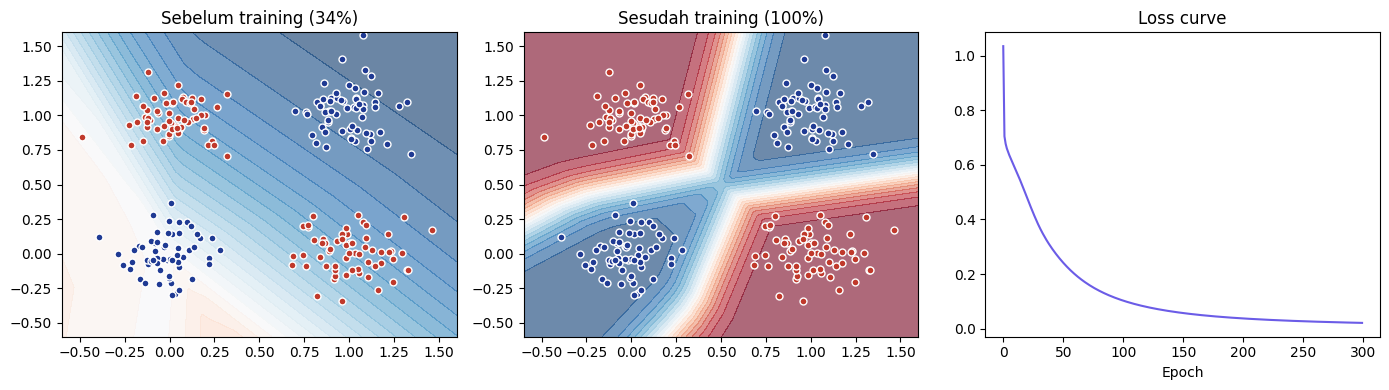

In [9]:
# Latih MLP manual dengan gradient descent, lalu lihat decision boundary-nya berubah.
W1, b1, W2, b2 = init_params()
y_hat0, _ = forward(X, W1, b1, W2, b2)
acc_before = ((y_hat0 > 0.5) == y).mean()

lr, losses = 0.5, []
for epoch in range(300):
    y_hat, cache = forward(X, W1, b1, W2, b2)
    losses.append(bce_loss(y_hat, y))
    dW1, db1, dW2, db2 = backward(y, cache, W2)
    W1 -= lr * dW1; b1 -= lr * db1
    W2 -= lr * dW2; b2 -= lr * db2

y_hat_final, _ = forward(X, W1, b1, W2, b2)
acc_after = ((y_hat_final > 0.5) == y).mean()
print(f"Akurasi: {acc_before:.0%} (acak) -> {acc_after:.0%} (setelah training)")

def plot_boundary(ax, W1, b1, W2, b2, title):
    xx, yy = np.meshgrid(np.linspace(-0.6, 1.6, 150), np.linspace(-0.6, 1.6, 150))
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs, _ = forward(grid, W1, b1, W2, b2)
    ax.contourf(xx, yy, probs.reshape(xx.shape), levels=20, cmap="RdBu_r", alpha=0.6, vmin=0, vmax=1)
    ax.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], c="#1f3a93", edgecolors="white", s=25)
    ax.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], c="#c0392b", edgecolors="white", s=25)
    ax.set_title(title)

W1i, b1i, W2i, b2i = init_params()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_boundary(axes[0], W1i, b1i, W2i, b2i, f"Sebelum training ({acc_before:.0%})")
plot_boundary(axes[1], W1, b1, W2, b2, f"Sesudah training ({acc_after:.0%})")
axes[2].plot(losses, color="#6b5ce7"); axes[2].set_title("Loss curve"); axes[2].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

---
## Bagian B — Dari NumPy ke `nn.Module` (Tugas 2)

Sekarang kita "port" arsitektur yang sama ke PyTorch. Tujuannya: **membuktikan**
bahwa `nn.Module` bukan sihir — dengan bobot yang sama persis, hasilnya harus identik
dengan implementasi manual di Bagian A.

### TODO 3 — Definisikan `XORNet(nn.Module)`

In [10]:
class XORNet(nn.Module):
    def __init__(self, in_dim=2, hid_dim=8, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hid_dim)
        self.fc2 = nn.Linear(hid_dim, out_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out

**Sel pemeriksa** — salin bobot manual ke `XORNet`, lalu bandingkan outputnya pada input yang sama. Harus identik (sampai galat numerik `float32` vs `float64`).

In [11]:
# ======================= PEMERIKSA BLOK 2 =======================
net = XORNet()
with torch.no_grad():
    net.fc1.weight.copy_(torch.tensor(W1.T, dtype=torch.float32))
    net.fc1.bias.copy_(torch.tensor(b1.flatten(), dtype=torch.float32))
    net.fc2.weight.copy_(torch.tensor(W2.T, dtype=torch.float32))
    net.fc2.bias.copy_(torch.tensor(b2.flatten(), dtype=torch.float32))

Xt32 = torch.tensor(X, dtype=torch.float32)
with torch.no_grad():
    module_out = net(Xt32).numpy()

max_diff = np.max(np.abs(y_hat_final - module_out))
print(f"Selisih maksimum manual vs nn.Module: {max_diff:.2e}")
assert max_diff < 1e-4, "nn.Module TIDAK cocok dengan implementasi manual — cek TODO 3!"
print(f"MATCH CONFIRMED! Total parameter XORNet: {sum(p.numel() for p in net.parameters())}")

Selisih maksimum manual vs nn.Module: 2.11e-07
MATCH CONFIRMED! Total parameter XORNet: 33


<details>
<summary>💡 Kode Penyelamat — XORNet</summary>

```python
class XORNet(nn.Module):
    def __init__(self, in_dim=2, hid_dim=8, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hid_dim)
        self.fc2 = nn.Linear(hid_dim, out_dim)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        out = torch.sigmoid(self.fc2(h))
        return out
```
</details>

---
## Bagian C — Training Loop Nyata di FashionMNIST (Tugas 3)

Cukup dengan toy data. Sekarang kita latih classifier MLP sungguhan pada **FashionMNIST**
(28x28 grayscale, 10 kelas pakaian) — dataset asli via `torchvision`, bukan tensor acak.
Supaya latihan tetap cepat di kelas, kita pakai subset kecil (4000 train / 1000 val).

### Data: FashionMNIST (subset)

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 255kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.51MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]


Train subset: 4000 | Val subset: 1000


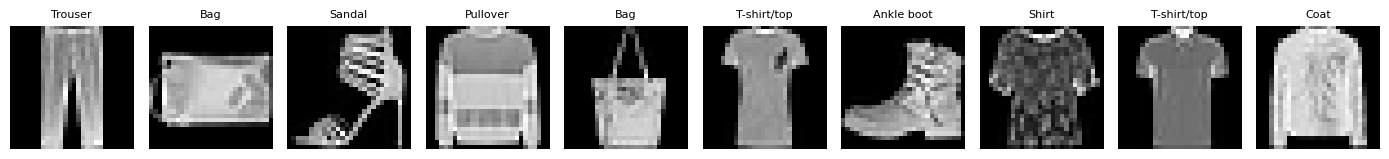

In [12]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

transform = T.Compose([T.ToTensor()])
full_train = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
full_test = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

rng = np.random.RandomState(0)
train_idx = rng.choice(len(full_train), 4000, replace=False)
val_idx = rng.choice(len(full_test), 1000, replace=False)
train_ds = Subset(full_train, train_idx)
val_ds = Subset(full_test, val_idx)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
print(f"Train subset: {len(train_ds)} | Val subset: {len(val_ds)}")

imgs, labels = next(iter(DataLoader(train_ds, batch_size=10, shuffle=True)))
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i, 0], cmap="gray"); ax.set_title(CLASS_NAMES[labels[i]], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

### TODO 4 — `VisualMLP` (nn.Module dengan BatchNorm & Dropout)

Arsitektur: `Linear -> BatchNorm1d -> ReLU -> Dropout -> Linear -> BatchNorm1d -> ReLU -> Linear`.
Isi fungsi aktivasi non-linear yang tepat pada dua titik kosong (`None`) — layer
**terakhir** sengaja TIDAK diberi aktivasi karena `nn.CrossEntropyLoss` sudah
menghitung Softmax secara internal (ingat catatan Bu Endah tentang ini!).

In [13]:
class VisualMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),  # output layer -> TANPA aktivasi (CrossEntropyLoss sudah include softmax)
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

### TODO 5 — Training Loop (Forward → Loss → Backward → Step)

Ini siklus training standar PyTorch yang baru dijelaskan di Sesi 2. Isi 5 langkahnya.

In [14]:
def evaluate(model, loader, criterion):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss_sum += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            all_preds.append(preds.numpy()); all_labels.append(labels.numpy())
    return loss_sum / total, correct / total * 100, np.concatenate(all_preds), np.concatenate(all_labels)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total * 100

**Sel pemeriksa** — latih `VisualMLP` selama 6 epoch dengan AdamW, lalu evaluasi. Sel ini juga menampilkan confusion matrix — perhatikan baik-baik kelas mana yang paling sering tertukar.

Epoch 1/6 - train_loss=1.0687 | val_acc=75.20%
Epoch 2/6 - train_loss=0.6103 | val_acc=79.00%
Epoch 3/6 - train_loss=0.4967 | val_acc=79.20%
Epoch 4/6 - train_loss=0.4382 | val_acc=81.70%
Epoch 5/6 - train_loss=0.3893 | val_acc=80.80%
Epoch 6/6 - train_loss=0.3446 | val_acc=82.10%

TRAINING BERHASIL & TERVERIFIKASI! val_acc akhir = 82.10%
Total parameter trainable: 235,914


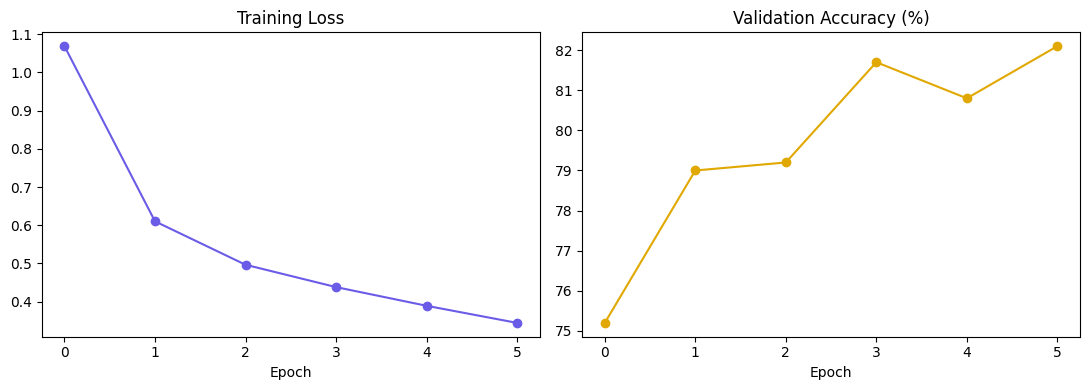

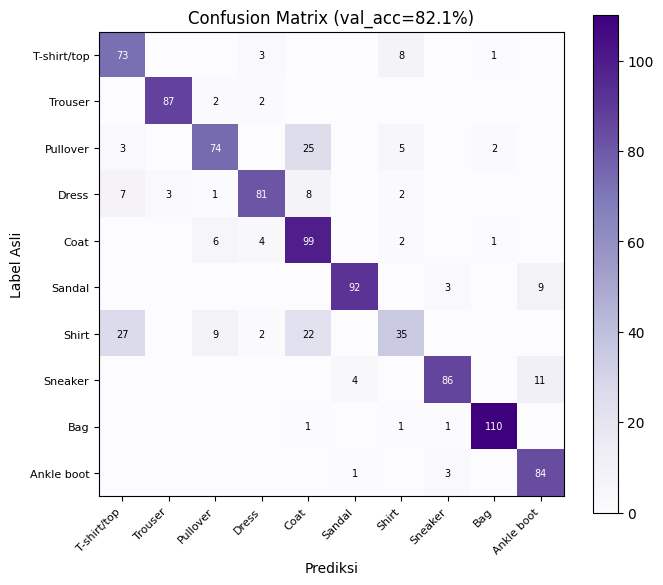


Pasangan kelas paling sering tertukar: 'Shirt' diprediksi sebagai 'T-shirt/top' (27x)


In [15]:
# ======================= PEMERIKSA BLOK 3 =======================
torch.manual_seed(0)
model = VisualMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

dummy = torch.randn(8, 1, 28, 28)
model.eval()
with torch.no_grad():
    out = model(dummy)
assert out.shape == (8, 10), f"Bentuk output VisualMLP salah: {out.shape} (harus (8, 10)) - cek TODO 4"

train_losses, val_accs = [], []
for epoch in range(6):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, preds, labels_all = evaluate(model, val_loader, criterion)
    train_losses.append(tr_loss); val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/6 - train_loss={tr_loss:.4f} | val_acc={val_acc:.2f}%")

assert train_losses[-1] < train_losses[0], "Loss training tidak turun sama sekali — cek TODO 5!"
assert val_accs[-1] > 60.0, f"Akurasi validasi terlalu rendah ({val_accs[-1]:.1f}%) — cek TODO 4/5!"
print(f"\nTRAINING BERHASIL & TERVERIFIKASI! val_acc akhir = {val_accs[-1]:.2f}%")
print(f"Total parameter trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(train_losses, marker="o", color="#6b5ce7"); axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")
axes[1].plot(val_accs, marker="o", color="#e0a800"); axes[1].set_title("Validation Accuracy (%)"); axes[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()

cm = np.zeros((10, 10), dtype=int)
for p, l in zip(preds, labels_all):
    cm[l, p] += 1
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("Prediksi"); ax.set_ylabel("Label Asli"); ax.set_title(f"Confusion Matrix (val_acc={val_accs[-1]:.1f}%)")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
i, j = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"\nPasangan kelas paling sering tertukar: '{CLASS_NAMES[i]}' diprediksi sebagai '{CLASS_NAMES[j]}' ({cm_off[i,j]}x)")

<details>
<summary>💡 Kode Penyelamat — VisualMLP & Training Loop</summary>

```python
class VisualMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total * 100
```
</details>

---
## Bonus — Perbandingan Optimizer & LR Scheduler (jika waktu tersisa)

Kode di bawah ini sudah lengkap (given) — tinggal jalankan. Perhatikan kurva
konvergensinya: inilah bukti visual kenapa Adam/AdamW jadi standar modern
dibanding SGD polos.

SGD: final_train_loss=0.3737 final_val_acc=82.00%
Adam: final_train_loss=0.3478 final_val_acc=81.50%
AdamW: final_train_loss=0.3497 final_val_acc=81.70%


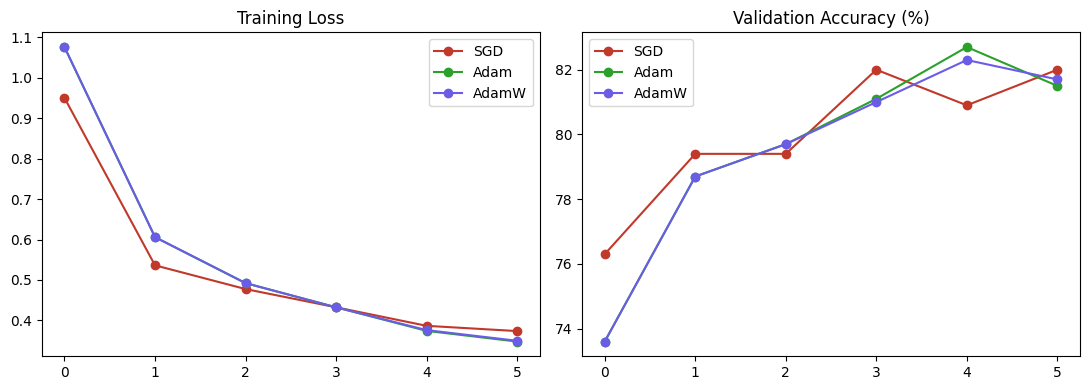

In [16]:
def train_config(optimizer_name, n_epochs=6):
    torch.manual_seed(0)
    model = VisualMLP()
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    losses, accs = [], []
    for _ in range(n_epochs):
        tr_loss, _ = train_one_epoch(model, train_loader, criterion, optimizer)
        _, val_acc, _, _ = evaluate(model, val_loader, criterion)
        losses.append(tr_loss); accs.append(val_acc)
    return losses, accs

results = {name: train_config(name) for name in ["SGD", "Adam", "AdamW"]}
for name, (l, a) in results.items():
    print(f"{name}: final_train_loss={l[-1]:.4f} final_val_acc={a[-1]:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = {"SGD": "#c0392b", "Adam": "#2ca02c", "AdamW": "#6b5ce7"}
for name, (l, a) in results.items():
    axes[0].plot(l, marker="o", label=name, color=colors[name])
    axes[1].plot(a, marker="o", label=name, color=colors[name])
axes[0].set_title("Training Loss"); axes[0].legend()
axes[1].set_title("Validation Accuracy (%)"); axes[1].legend()
plt.tight_layout(); plt.show()

---
## Pertanyaan Refleksi

Jawab singkat (2-3 kalimat) di sel Markdown di bawah tiap pertanyaan.

**1. Kenapa dataset XOR tidak bisa dipisahkan oleh satu perceptron (tanpa hidden layer),**
**dan bagaimana hidden layer + fungsi aktivasi non-linear menyelesaikannya?**

*Jawab:* Dataset XOR tidak bisa dipisahkan dengan satu perceptron karena datanya tidak linearly separable. Hidden layer dan aktivasi non-linear membuat model bisa membentuk batas keputusan yang lebih kompleks.

**2. Dari hasil gradient check di Bagian A, apa gunanya membandingkan gradien manual**
**dengan `torch.autograd`? Kenapa ini penting sebelum kita percaya penuh pada training loop di Bagian C?**

*Jawab:* Gradient check digunakan untuk memastikan gradien yang dihitung manual sudah benar dengan membandingkannya dengan torch.autograd. Ini penting supaya kesalahan pada perhitungan gradien tidak membuat proses training di Bagian C menjadi salah.

**3. Lihat confusion matrix di Bagian C — kelas apa yang paling sering tertukar? Menurutmu**
**kenapa MLP (bukan CNN) kesulitan membedakan pasangan kelas tersebut?**

*Jawab:* Kelas yang paling sering tertukar dapat dilihat dari nilai terbesar di luar diagonal confusion matrix. MLP kesulitan membedakannya karena gambar di-flatten, sehingga informasi posisi dan hubungan antar piksel tidak dimanfaatkan sebaik CNN.

---
## Penutup — Jembatan ke Minggu 4

MLP yang baru kalian latih meng-*flatten* gambar 28x28 menjadi vektor 784 angka —
informasi spasial (piksel mana bertetangga dengan piksel mana) hilang sama sekali.
Itu sebabnya `VisualMLP` "buta" terhadap posisi objek dalam gambar, dan kenapa untuk
citra resolusi tinggi jumlah parameternya meledak (ingat poin ini juga disebut di
slide teori Sesi 1). **Minggu 4** akan memperkenalkan *Convolutional Neural Networks*
— arsitektur yang mempertahankan struktur spasial gambar lewat operasi konvolusi.